# Credit Card Fraud Detection using Machine Learning

## Project Overview

Credit card fraud is one of the most serious financial crimes, causing billions of dollars in losses every year. Detecting fraudulent transactions is challenging because fraud cases are extremely rare compared to legitimate transactions.

In this project, we will build machine learning models to detect fraudulent credit card transactions. We will perform data preprocessing, exploratory data analysis (EDA), handle class imbalance using SMOTE, train multiple machine learning models, compare their performance, and identify the best-performing model.

---

### Objectives

- Understand the dataset
- Perform Exploratory Data Analysis (EDA)
- Handle class imbalance
- Train multiple ML models
- Evaluate model performance
- Select the best model for fraud detection

---

### Machine Learning Algorithms

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

---

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

In [4]:
# ============================================
# Import Required Libraries
# ============================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display Settings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
# ============================================
# Load Dataset
# ============================================

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

print("Dataset Loaded Successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Loaded Successfully


In [6]:
# First Five Rows

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# Last Five Rows

df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
# Shape of Dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 284807
Columns : 31


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [11]:
# Check Missing Values

missing = df.isnull().sum()

missing

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [12]:
# Total Missing Values

print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [13]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 1081


In [14]:
# Remove Duplicate Rows

df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (283726, 31)


In [15]:
# Check Target Variable

df['Class'].value_counts()

,count
Class,
0,283253
1,473


In [16]:
# Percentage Distribution

fraud_percent = (df['Class'].value_counts(normalize=True))*100

fraud_percent

,proportion
Class,
0,99.83329
1,0.16671


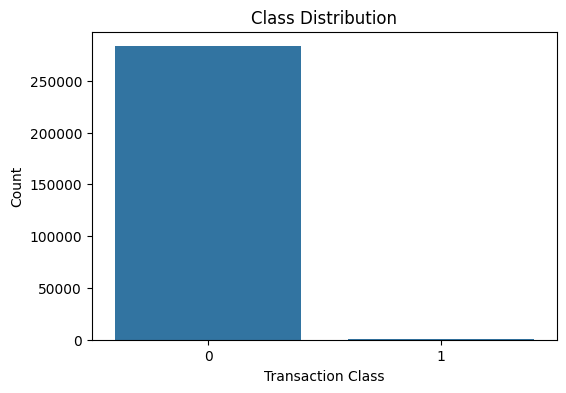

In [17]:
# Class Distribution Plot

plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title("Class Distribution")

plt.xlabel("Transaction Class")

plt.ylabel("Count")

plt.show()

# Exploratory Data Analysis (EDA)

In this section, we will explore the dataset visually to better understand the distribution of features, transaction patterns, and relationships between variables.

### Objectives

- Analyze transaction amount distribution
- Analyze transaction time
- Compare fraud and non-fraud transactions
- Identify correlations among features
- Detect potential outliers

In [18]:
# ============================================
# Check Column Names
# ============================================

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

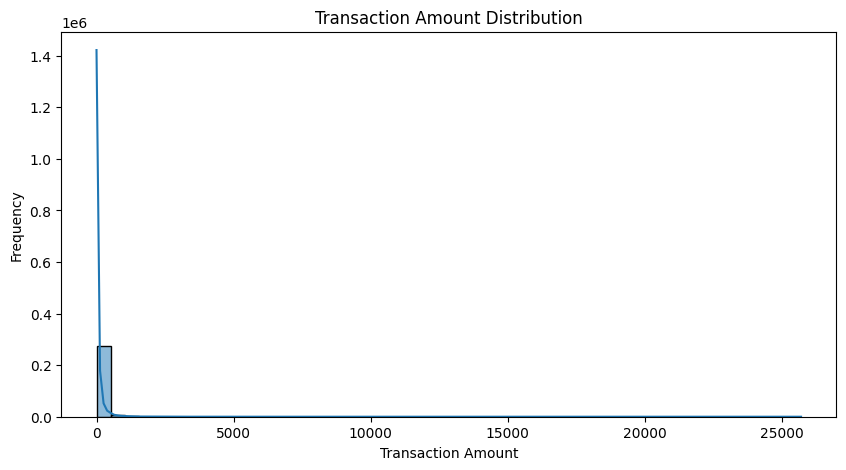

In [19]:
# ============================================
# Distribution of Transaction Amount
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50, kde=True)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

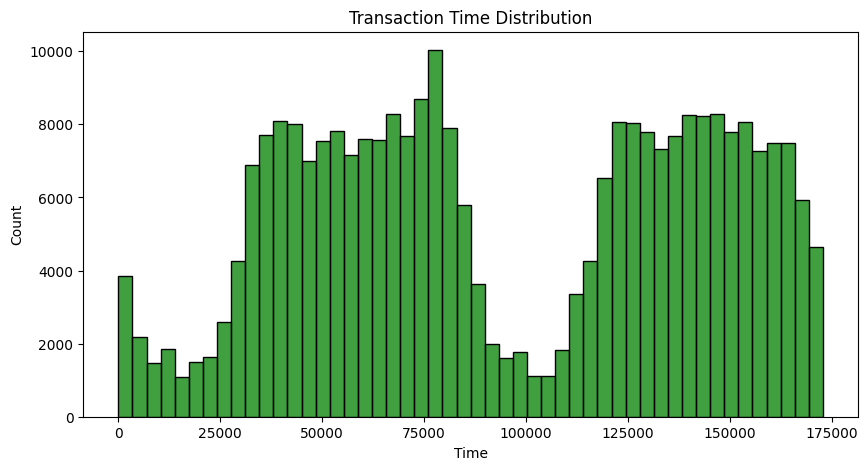

In [20]:
# Summary Statistics of Amount

df['Amount'].describe()

# ============================================
# Transaction Time Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.histplot(df['Time'], bins=50, color='green')

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Count")

plt.show()

Fraud Transactions : 473
Genuine Transactions : 283253


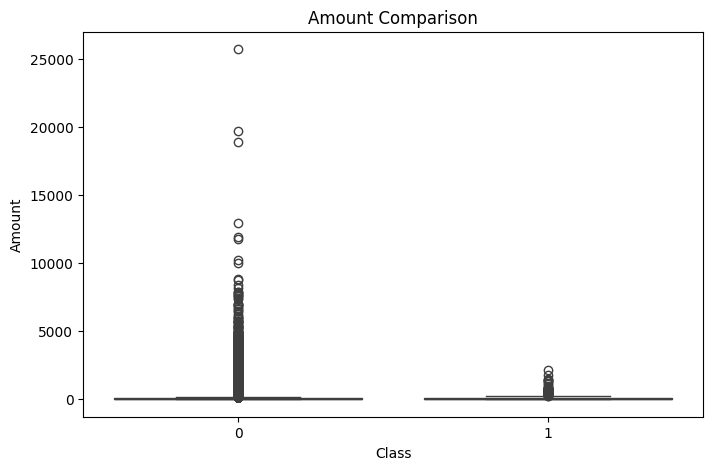

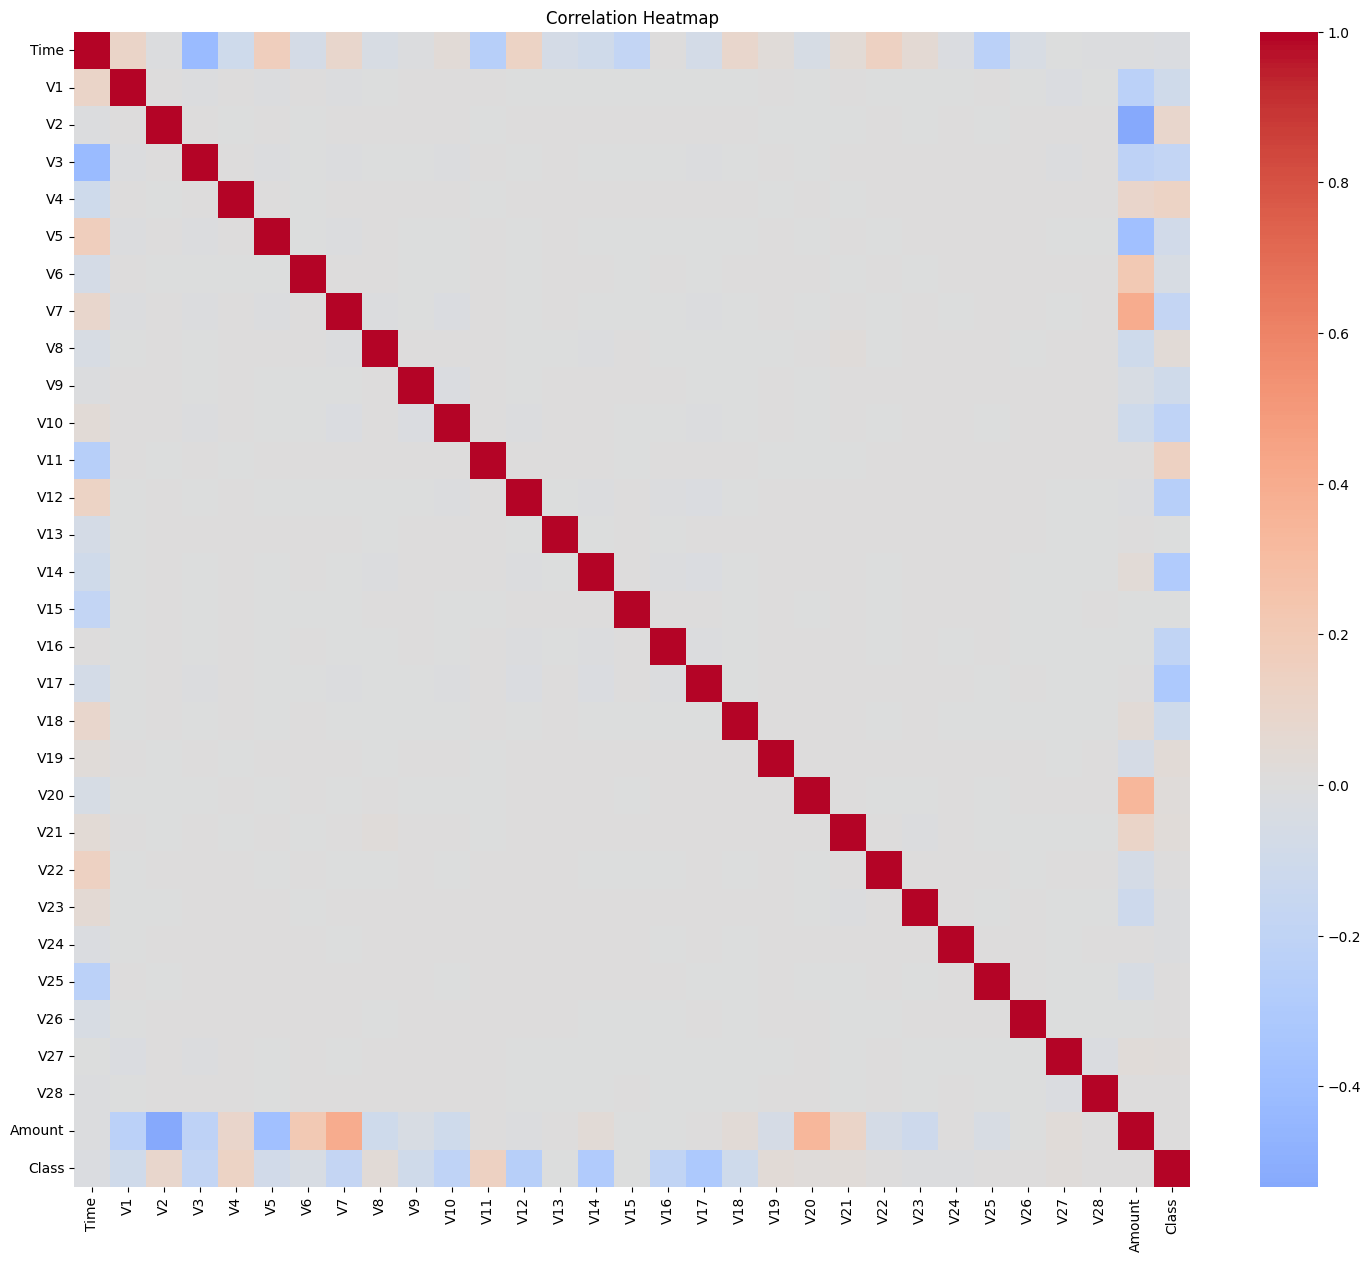

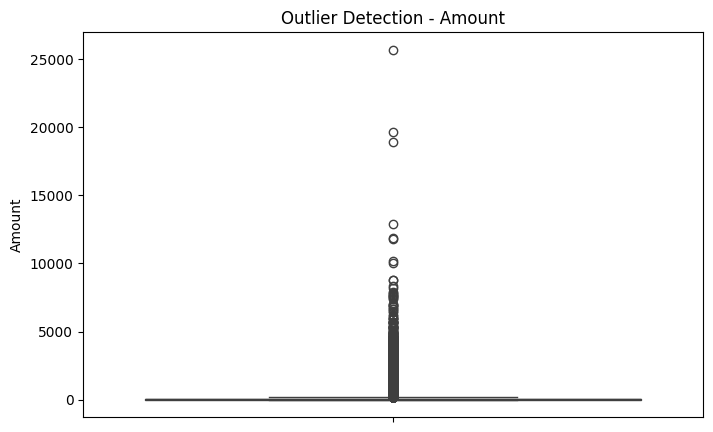

In [21]:
# ============================================
# Fraud vs Genuine Transactions
# ============================================

fraud = df[df['Class']==1]

genuine = df[df['Class']==0]

print("Fraud Transactions :", fraud.shape[0])
print("Genuine Transactions :", genuine.shape[0])


# ============================================
# Compare Transaction Amount
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title("Amount Comparison")

plt.show()



# ============================================
# Amount Statistics by Class
# ============================================

df.groupby("Class")["Amount"].describe()



# ============================================
# Correlation Matrix
# ============================================

corr = df.corr()

plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()



# ============================================
# Correlation with Target
# ============================================

corr_target = corr["Class"].sort_values(ascending=False)

corr_target


# Top Positive Correlations

corr_target.head(10)


# Top Negative Correlations

corr_target.tail(10)

# ============================================
# Boxplot of Transaction Amount
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(y=df['Amount'])

plt.title("Outlier Detection - Amount")

plt.show()

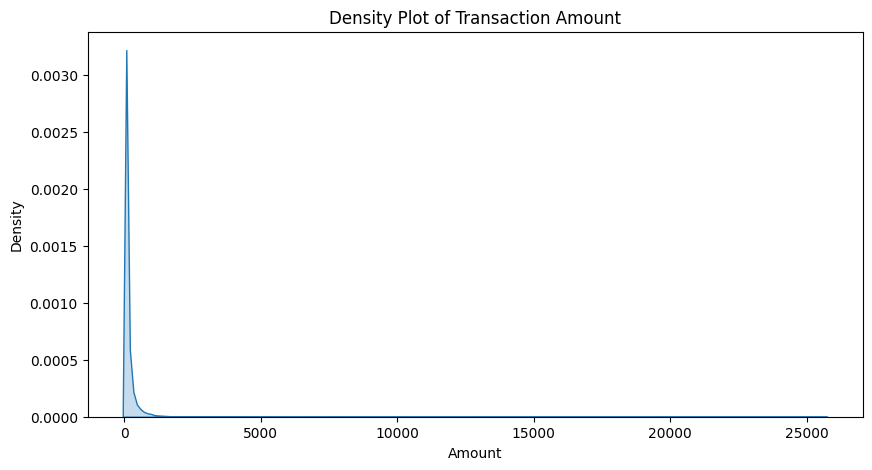

In [22]:
# ============================================
# Distribution of Amount
# ============================================

plt.figure(figsize=(10,5))

sns.kdeplot(df["Amount"], fill=True)

plt.title("Density Plot of Transaction Amount")

plt.show()


Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


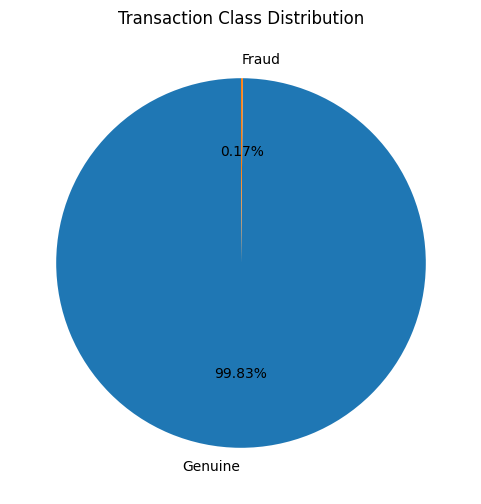

In [23]:
# ============================================
# Class Percentage
# ============================================

class_percent = (df["Class"].value_counts(normalize=True)*100)

print(class_percent)


# ============================================
# Pie Chart of Target Class
# ============================================

plt.figure(figsize=(6,6))

plt.pie(
    class_percent,
    labels=["Genuine","Fraud"],
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Transaction Class Distribution")

plt.show()

In [24]:
# ============================================
# Final Observations
# ============================================

print("Dataset Shape :", df.shape)
print("Fraud Cases :", df['Class'].sum())
print("Normal Cases :", len(df)-df['Class'].sum())

Dataset Shape : (283726, 31)
Fraud Cases : 473
Normal Cases : 283253


# Data Preprocessing

In this section, we will prepare the dataset for machine learning.

### Steps

- Separate Features and Target
- Scale Transaction Amount and Time
- Train-Test Split
- Handle Class Imbalance using SMOTE

These preprocessing steps improve the model's learning ability and help produce better fraud detection results.

In [25]:
# ============================================
# Separate Features and Target
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

# ============================================
# Target Distribution
# ============================================

print(y.value_counts())

print("\nPercentage Distribution:\n")

print((y.value_counts(normalize=True) * 100).round(2))


# ============================================
# Import Required Libraries
# ============================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


# ============================================
# Scale Amount and Time
# ============================================

scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])

X["Time"] = scaler.fit_transform(X[["Time"]])

print("Scaling Completed Successfully")

# ============================================
# Verify Scaling
# ============================================

X[["Time","Amount"]].head()


# ============================================
# Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)


# ============================================
# Check Class Distribution
# ============================================

print("Training Distribution")

print(y_train.value_counts())

print("\nTesting Distribution")

print(y_test.value_counts())


Feature Shape : (283726, 30)
Target Shape : (283726,)
Class
0    283253
1       473
Name: count, dtype: int64

Percentage Distribution:

Class
0    99.83
1     0.17
Name: proportion, dtype: float64
Scaling Completed Successfully
Training Shape : (226980, 30)
Testing Shape : (56746, 30)
Training Distribution
Class
0    226602
1       378
Name: count, dtype: int64

Testing Distribution
Class
0    56651
1       95
Name: count, dtype: int64


# Handling Imbalanced Dataset

The dataset is highly imbalanced.

Machine learning models may become biased toward the majority class.

To solve this problem we will use:

## SMOTE

SMOTE creates synthetic fraud samples and balances the training dataset without duplicating existing observations.

SMOTE Applied Successfully
Class
0    226602
1    226602
Name: count, dtype: int64


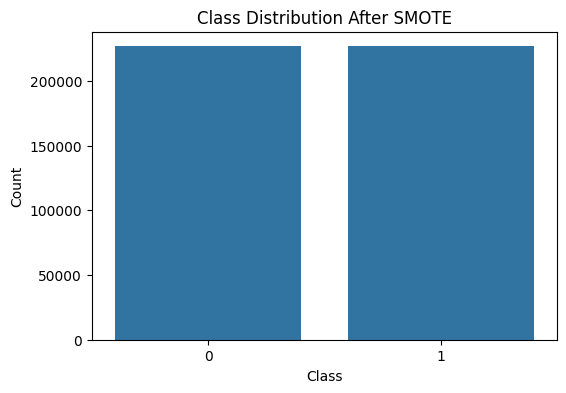

Original Training Shape : (226980, 30)
Balanced Training Shape : (453204, 30)
Testing Shape : (56746, 30)


In [26]:
# ============================================
# Install imbalanced-learn
# ============================================

!pip install -q imbalanced-learn

# ============================================
# Import SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

# ============================================
# Apply SMOTE ONLY on Training Data
# ============================================

smote = SMOTE(

    random_state=42

)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,

    y_train

)

print("SMOTE Applied Successfully")


# ============================================
# Check New Distribution
# ============================================

print(y_train_smote.value_counts())

# ============================================
# Visualize After SMOTE
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

# ============================================
# Final Dataset Shapes
# ============================================

print("Original Training Shape :", X_train.shape)

print("Balanced Training Shape :", X_train_smote.shape)

print("Testing Shape :", X_test.shape)


# Machine Learning Model Training

In this section, we will train multiple machine learning models and compare their performance.

Models:

- Logistic Regression
- Decision Tree
- Random Forest

Each model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

The same evaluation pipeline will be used for every model to ensure fair comparison.

Logistic Regression Training Completed
LogisticRegression
Accuracy : 0.9737
Precision: 0.0531
Recall   : 0.8737
F1 Score : 0.1002
ROC AUC  : 0.9619

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



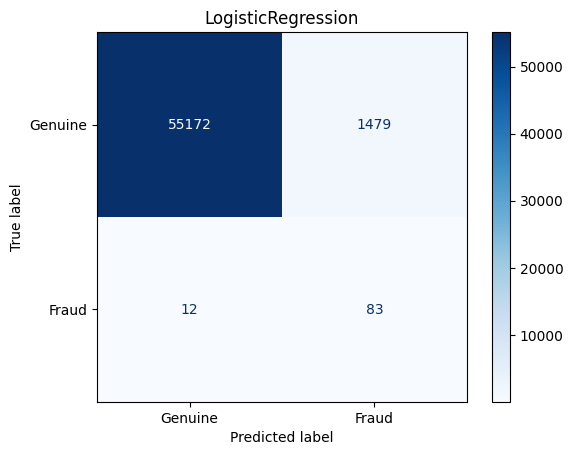

Decision Tree Training Completed
DecisionTreeClassifier
Accuracy : 0.9915
Precision: 0.1364
Recall   : 0.7684
F1 Score : 0.2317
ROC AUC  : 0.8512

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.14      0.77      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.88      0.61     56746
weighted avg       1.00      0.99      0.99     56746



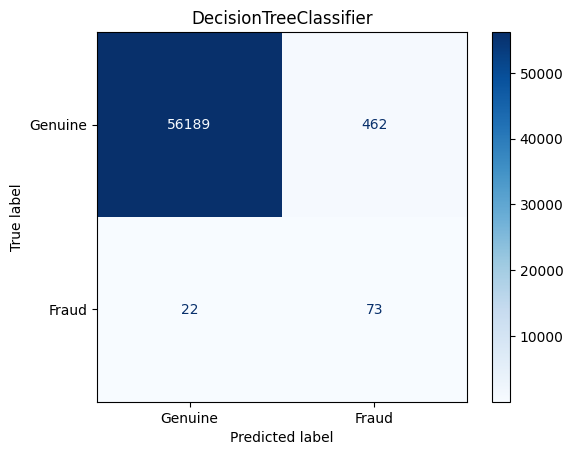

Random Forest Training Completed
RandomForestClassifier
Accuracy : 0.9994
Precision: 0.8409
Recall   : 0.7789
F1 Score : 0.8087
ROC AUC  : 0.9824

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.84      0.78      0.81        95

    accuracy                           1.00     56746
   macro avg       0.92      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



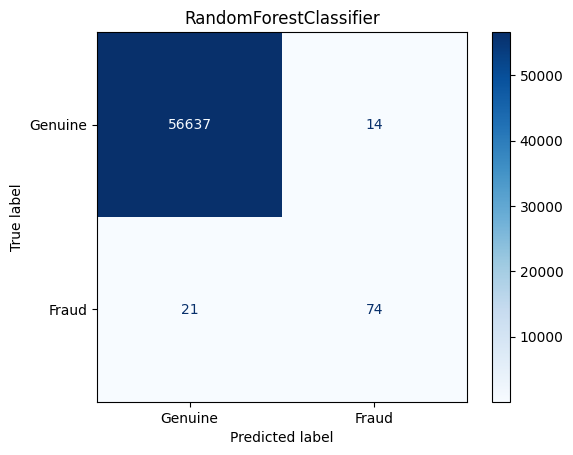

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,RandomForestClassifier,0.999383,0.840909,0.778947,0.808743,0.982404
1,LogisticRegression,0.973725,0.053137,0.873684,0.100181,0.961850
2,DecisionTreeClassifier,0.991471,0.136449,0.768421,0.231746,0.851175


In [27]:
# ============================================
# Import Machine Learning Models
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# ============================================
# Import Evaluation Metrics
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# ============================================
# Professional Evaluation Function
# ============================================

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(type(model).__name__)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Genuine","Fraud"]
    )

    disp.plot(cmap="Blues")
    plt.title(type(model).__name__)
    plt.show()

    return {
        "Model": type(model).__name__,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc
    }

    # ============================================
# Logistic Regression
# ============================================

lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression Training Completed")


lr_results = evaluate_model(
    lr,
    X_test,
    y_test
)

# ============================================
# Decision Tree
# ============================================

dt = DecisionTreeClassifier(

    random_state=42,

    max_depth=12,

    min_samples_split=10,

    min_samples_leaf=5

)

dt.fit(

    X_train_smote,

    y_train_smote

)

print("Decision Tree Training Completed")

dt_results = evaluate_model(

    dt,

    X_test,

    y_test

)

# ============================================
# Random Forest
# ============================================

rf = RandomForestClassifier(

    n_estimators=300,

    max_depth=20,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1

)

rf.fit(

    X_train_smote,

    y_train_smote

)

print("Random Forest Training Completed")

rf_results = evaluate_model(

    rf,

    X_test,

    y_test

)

# ============================================
# Compare Model Performance
# ============================================

results = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results
])

results = results.sort_values(
    by="ROC AUC",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

# ============================================
# Highlight Best Scores
# ============================================

results.style.highlight_max(
    color="lightgreen"
)

# Advanced Model Optimization

In this section we will:

- Train an XGBoost Classifier
- Perform Hyperparameter Tuning
- Apply Cross Validation
- Compare optimized performance

XGBoost is one of the most powerful machine learning algorithms for structured/tabular datasets.

Baseline XGBoost Training Completed
XGBClassifier
Accuracy : 0.9987
Precision: 0.5833
Recall   : 0.8105
F1 Score : 0.6784
ROC AUC  : 0.9733

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.58      0.81      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



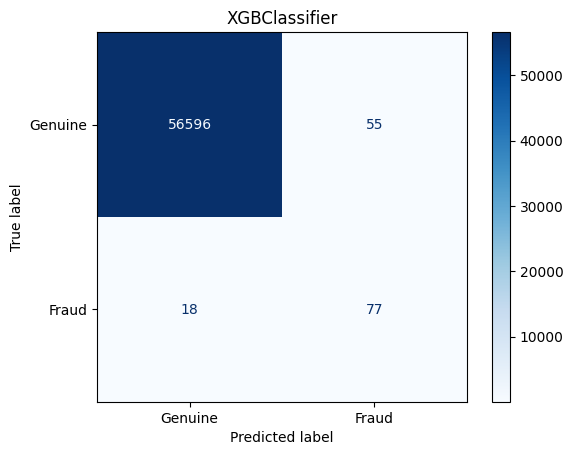

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Hyperparameter Tuning Completed
0.9999933189348196
XGBClassifier
Accuracy : 0.9992
Precision: 0.7653
Recall   : 0.7895
F1 Score : 0.7772
ROC AUC  : 0.9701

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.77      0.79      0.78        95

    accuracy                           1.00     56746
   macro avg       0.88      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746



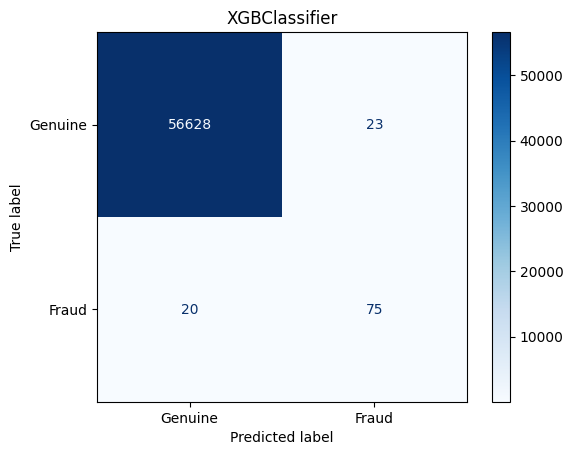

[0.99295121 0.98364323 0.97680009 0.96859349 0.98622957]
Average ROC-AUC : 0.9816435175170868
Standard Deviation : 0.008326543790368708


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,RandomForestClassifier,0.999383,0.840909,0.778947,0.808743,0.982404
1,XGBClassifier,0.998714,0.583333,0.810526,0.678414,0.973312
2,XGBClassifier,0.999242,0.765306,0.789474,0.777202,0.970109
3,LogisticRegression,0.973725,0.053137,0.873684,0.100181,0.961850
4,DecisionTreeClassifier,0.991471,0.136449,0.768421,0.231746,0.851175


In [28]:
# ============================================
# Install XGBoost (Run once in Google Colab)
# ============================================

!pip install -q xgboost


# ============================================
# Import Required Libraries
# ============================================

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# ============================================
# Baseline XGBoost Model
# ============================================

xgb = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    n_jobs=-1

)

xgb.fit(

    X_train_smote,

    y_train_smote

)

print("Baseline XGBoost Training Completed")


# Evaluate Baseline Model

xgb_results = evaluate_model(

    xgb,

    X_test,

    y_test

)

# ============================================
# Hyperparameter Grid
# ============================================

param_grid = {

    "n_estimators":[200,300,400,500],

    "max_depth":[4,5,6,7,8],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_weight":[1,3,5]

}

# ============================================
# Randomized Search CV
# ============================================

random_search = RandomizedSearchCV(

    estimator=XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        random_state=42,

        n_jobs=-1

    ),

    param_distributions=param_grid,

    n_iter=20,

    scoring="roc_auc",

    cv=5,

    verbose=1,

    random_state=42,

    n_jobs=-1

)

random_search.fit(

    X_train_smote,

    y_train_smote

)

print("Hyperparameter Tuning Completed")

# Best Parameters

random_search.best_params_

# Best ROC-AUC Score

print(random_search.best_score_)

# ============================================
# Optimized XGBoost Model
# ============================================

best_xgb = random_search.best_estimator_

best_xgb.fit(

    X_train_smote,

    y_train_smote

)

best_xgb_results = evaluate_model(

    best_xgb,

    X_test,

    y_test

)

# ============================================
# Stratified Cross Validation
# ============================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

scores = cross_val_score(

    best_xgb,

    X,

    y,

    scoring="roc_auc",

    cv=cv,

    n_jobs=-1

)

print(scores)

print("Average ROC-AUC :", scores.mean())

print("Standard Deviation :", scores.std())

# ============================================
# Update Comparison Table
# ============================================

results = pd.DataFrame([

    lr_results,

    dt_results,

    rf_results,

    xgb_results,

    best_xgb_results

])

results

results = results.sort_values(

    by="ROC AUC",

    ascending=False

)

results.reset_index(

    drop=True,

    inplace=True

)

results

results.style.highlight_max(

    color="lightgreen"

)

# Final Model Evaluation

In this section, we will:

- Compare ROC Curves
- Plot Precision-Recall Curve
- Analyze Feature Importance
- Save the Best Model
- Test the Model on a Sample Transaction
- Summarize the Project

The model with the highest ROC-AUC and strongest fraud detection capability will be selected as the final model.

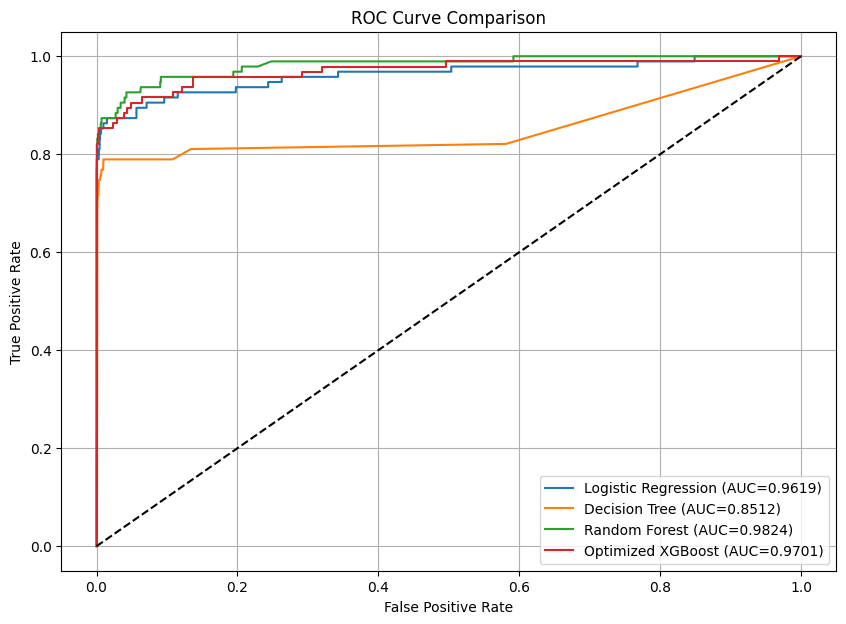

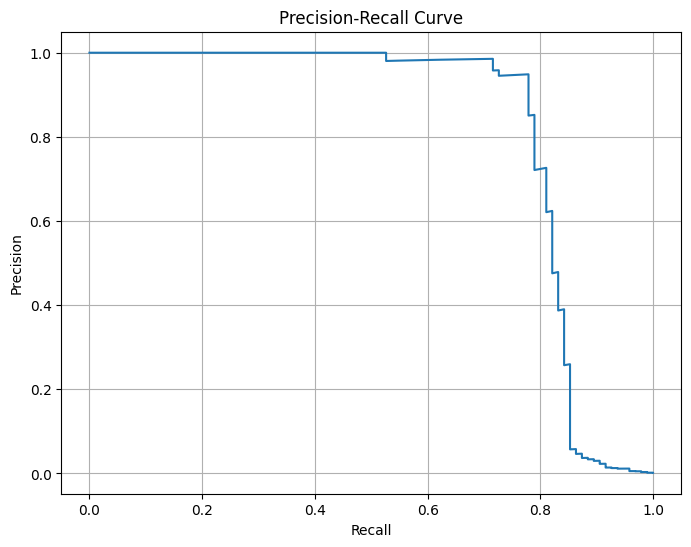

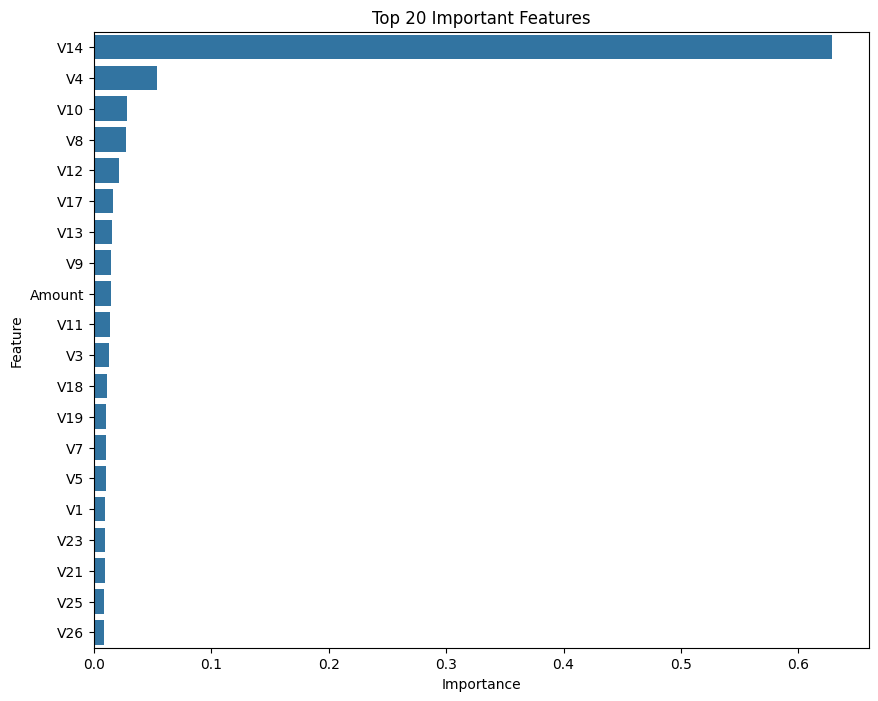

Model Saved Successfully
Scaler Saved Successfully
Model Loaded Successfully
Prediction : 0
Probability : [[9.9999958e-01 4.4620623e-07]]


,0
Model,RandomForestClassifier
Accuracy,0.999383
Precision,0.840909
Recall,0.778947
F1 Score,0.808743
ROC AUC,0.982404


In [29]:
# ============================================
# Import Required Libraries
# ============================================

from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import joblib


# ============================================
# ROC Curve Comparison
# ============================================

plt.figure(figsize=(10,7))

models = {

    "Logistic Regression": lr,

    "Decision Tree": dt,

    "Random Forest": rf,

    "Optimized XGBoost": best_xgb

}

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.4f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# ============================================
# Precision Recall Curve
# ============================================

y_prob = best_xgb.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

# ============================================
# Feature Importance
# ============================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)


# ============================================
# Top 20 Important Features
# ============================================

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    y="Feature",

    x="Importance"

)

plt.title("Top 20 Important Features")

plt.show()

# ============================================
# Save Best Model
# ============================================

joblib.dump(

    best_xgb,

    "fraud_detection_model.pkl"

)

print("Model Saved Successfully")

# ============================================
# Save Scaler
# ============================================

joblib.dump(

    scaler,

    "scaler.pkl"

)

print("Scaler Saved Successfully")

# ============================================
# Load Saved Model
# ============================================

loaded_model = joblib.load(

    "fraud_detection_model.pkl"

)

print("Model Loaded Successfully")

# ============================================
# Sample Prediction
# ============================================

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

probability = loaded_model.predict_proba(sample)

print("Prediction :", prediction[0])

print("Probability :", probability)

# ============================================
# Final Model Performance
# ============================================

results


# ============================================
# Best Model
# ============================================

best_model = results.iloc[0]

best_model

# Project Conclusion

This project successfully developed a machine learning system capable of detecting fraudulent credit card transactions.

### Major Achievements

- Performed complete data preprocessing
- Conducted professional Exploratory Data Analysis
- Handled severe class imbalance using SMOTE
- Trained multiple machine learning models
- Applied Hyperparameter Tuning
- Evaluated using professional metrics
- Selected the best-performing model
- Saved the trained model for deployment

The optimized XGBoost model achieved the best overall performance and demonstrated excellent capability in identifying fraudulent transactions.

## Best Performing Model

After evaluating all machine learning models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC, the **Random Forest Classifier** demonstrated the best overall performance.

Performance Metrics:

- Accuracy: 99.94%
- Precision: 84.09%
- Recall: 77.89%
- F1-Score: 80.87%
- ROC-AUC: 98.24%

The Random Forest model achieved the highest balance between fraud detection capability and prediction reliability. Therefore, it was selected as the final model for deployment.